# Analisis descriptivo de los datos climaticos

In [8]:
!python -m pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [6]:
!python -m pip install pandas numpy matplotlib


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.7 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.7 MB 3.0 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.7 MB 5.0 MB/s eta 0:00:02
   ------------- -------------------------- 3.4/9.7 MB 5.1 MB/s eta 0:00:02
   ---------------------------------------  9.7/9.7 MB 11.7 MB/s eta 0:00:01
   ---------------------------------------- 9.7/9.7 MB 11.0 MB/s  0:00:00
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---------- ----------------------------- 3.1/12.3 MB 16.1 MB/s eta 0:00:01
   --------------------------- ------------ 8.4/12.3 MB 20.3 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 19.2 MB/s  0:00:00
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   -------------- ------------------------- 2.9/8.1 MB 14.1 MB/s eta 0:00:01
   -------------------------------------

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Carga de datos y analisis inicial

In [40]:
df = pd.read_csv('wunderground_ezeiza_2001_2026.csv')
# Ver las primeras filas
print("Las primeras filas son: \n")
print(df.head())
print("\n")

Las primeras filas son: 

   day  temp_max_f  temp_avg_f  temp_min_f  dew_max_f  dew_avg_f  dew_min_f  \
0    1          91        80.9          66         64       59.1         55   
1    2          95        84.1          72         70       66.2         64   
2    3          91        83.8          72         70       66.5         61   
3    4          95        85.0          75         73       69.9         66   
4    5          97        80.3           0         73       64.4          0   

   humidity_max  humidity_avg  humidity_min  ...  wind_avg_mph  wind_min_mph  \
0            78          49.2            31  ...           6.8             0   
1            78          56.3            39  ...           6.3             0   
2            88          57.9            36  ...           5.5             1   
3            89          62.4            41  ...           4.5             0   
4            83          53.6             0  ...           5.2             0   

   pressure_max_in

In [41]:
# Ver estadísticas descriptivas
print("Los estadisticos principales son:")
print(df.describe())

Los estadisticos principales son:
               day   temp_max_f   temp_avg_f   temp_min_f    dew_max_f  \
count  9179.000000  9179.000000  9179.000000  9179.000000  9179.000000   
mean     15.719142    72.587210    62.620928    49.498202    57.708792   
std       8.796258    11.841534    11.030567    17.300633     9.824149   
min       1.000000    39.000000    25.900000   -17.000000    25.000000   
25%       8.000000    63.000000    54.200000    43.000000    50.000000   
50%      16.000000    73.000000    62.900000    52.000000    59.000000   
75%      23.000000    82.000000    71.200000    61.000000    64.000000   
max      31.000000   196.000000    94.100000    86.000000    90.000000   

         dew_avg_f    dew_min_f  humidity_max  humidity_avg  humidity_min  \
count  9179.000000  9179.000000   9179.000000   9179.000000   9179.000000   
mean     52.095501    42.082471     92.779061     72.178745     44.698333   
std      10.545009    17.880534      8.676581     12.816076     20.0

In [42]:
# Valores nulos
print("Los valores nulos son: \n")
print(df.isnull().sum())

Los valores nulos son: 

day                0
temp_max_f         0
temp_avg_f         0
temp_min_f         0
dew_max_f          0
dew_avg_f          0
dew_min_f          0
humidity_max       0
humidity_avg       0
humidity_min       0
wind_max_mph       0
wind_avg_mph       0
wind_min_mph       0
pressure_max_in    0
pressure_avg_in    0
pressure_min_in    0
precip_total_in    0
date               0
year               0
month              0
source_url         0
dtype: int64


In [43]:
df = df.drop(columns=["precip_total_in"])

Aca se puede evidenciar que no hay valores nulos pero si hay valores atipicos en la temperatura, queda ver que otros valores atipicos pueden haber.

In [44]:
# Boxplot para cada columna numerica
df.select_dtypes(include="number").boxplot(figsize=(16,8), rot=90)

<Axes: >

Se pueden observar multipls valores atipicos, observemos cada una de ellas

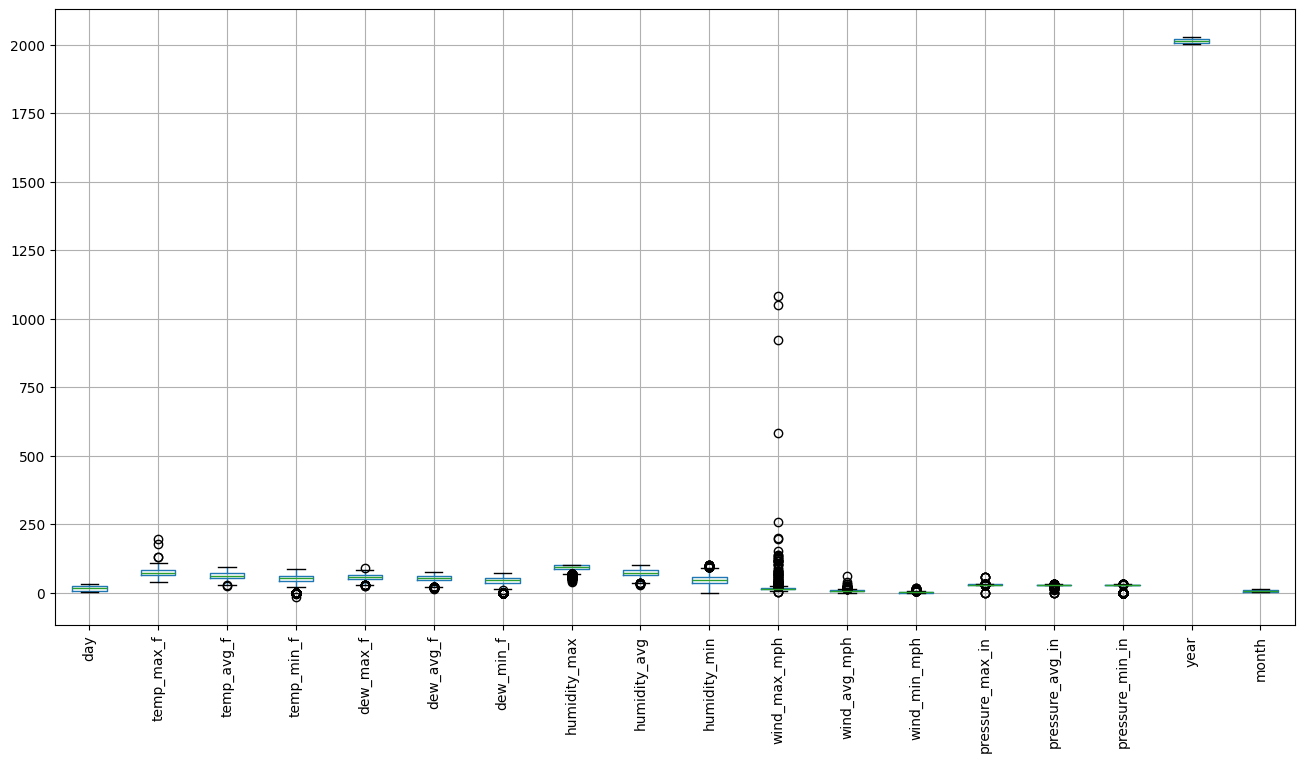

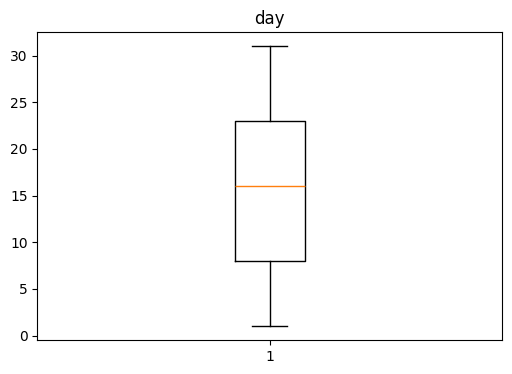

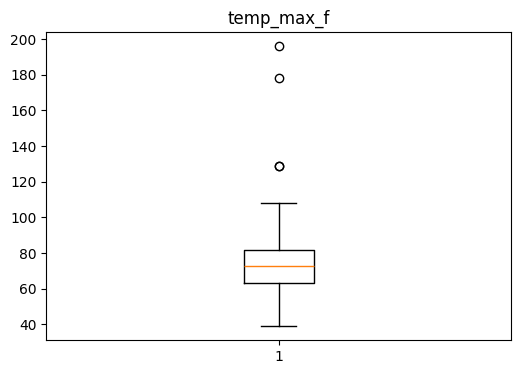

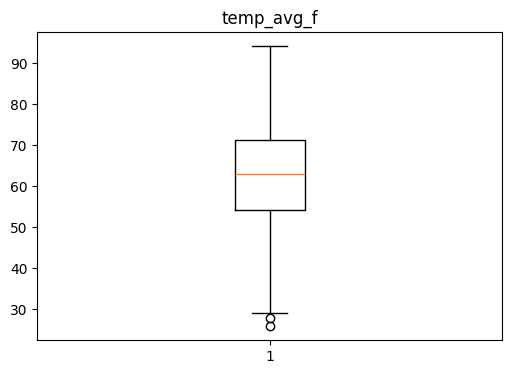

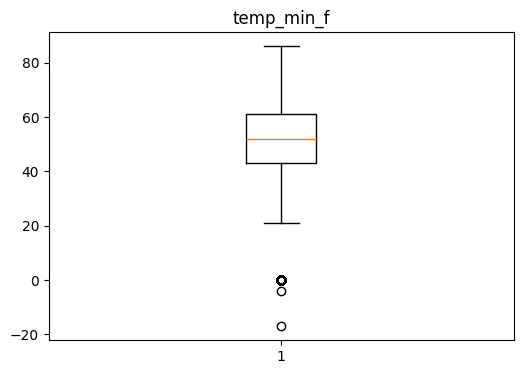

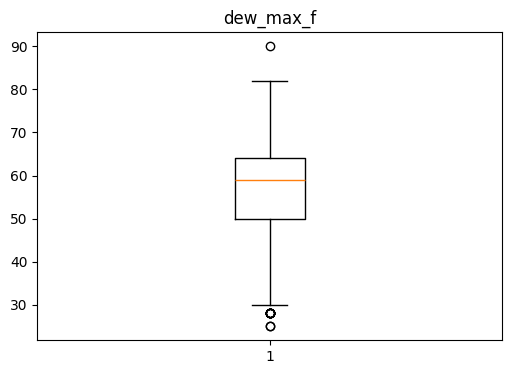

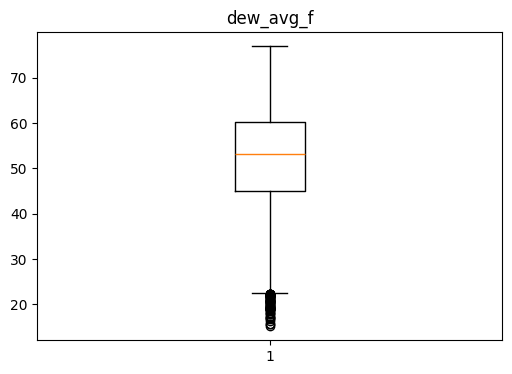

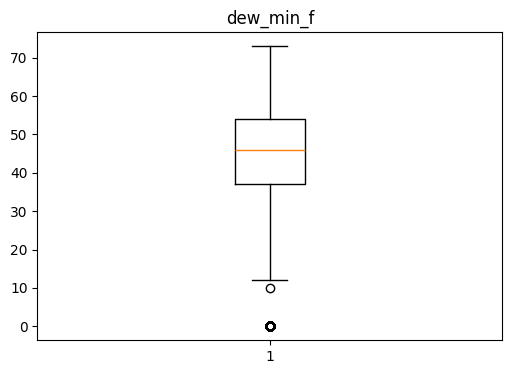

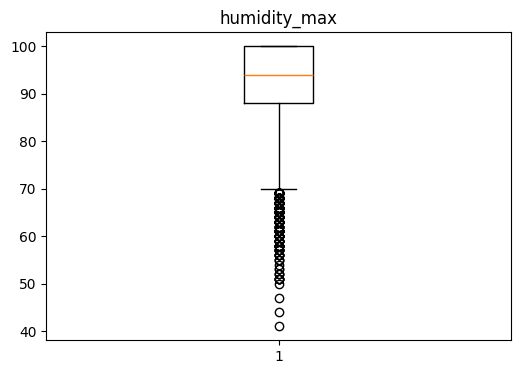

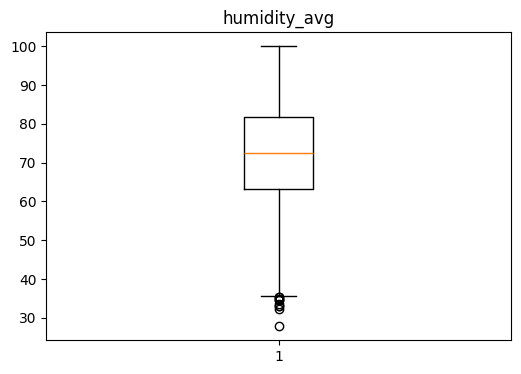

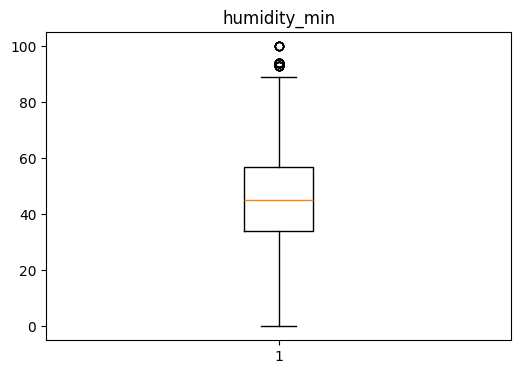

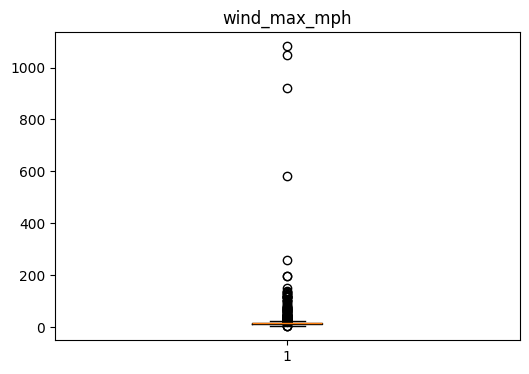

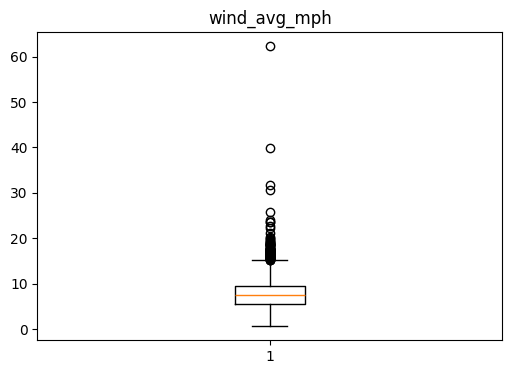

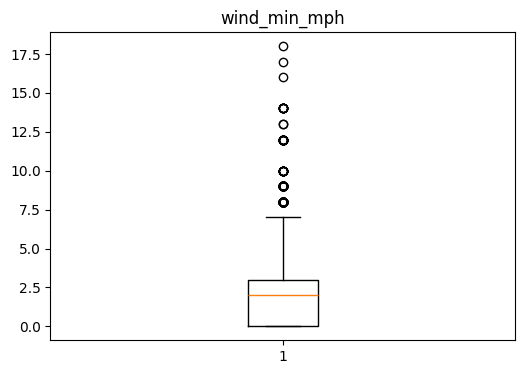

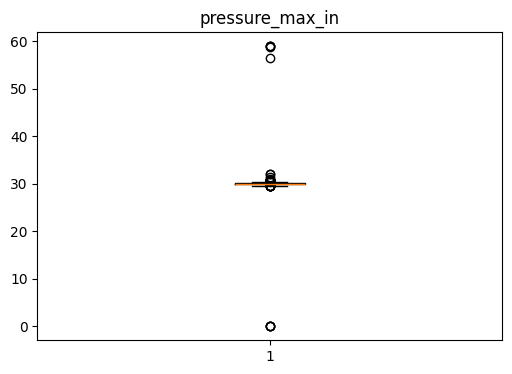

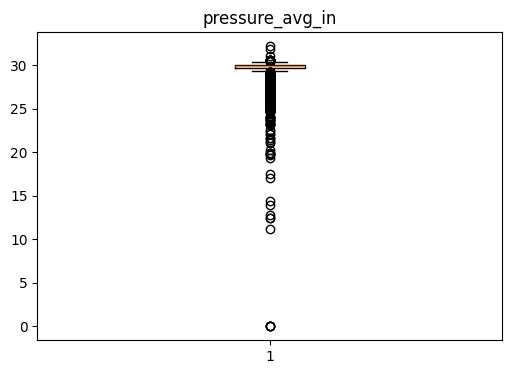

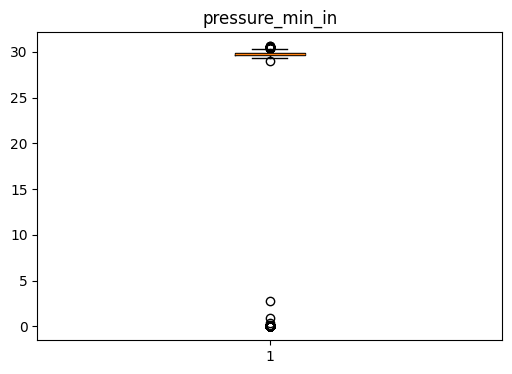

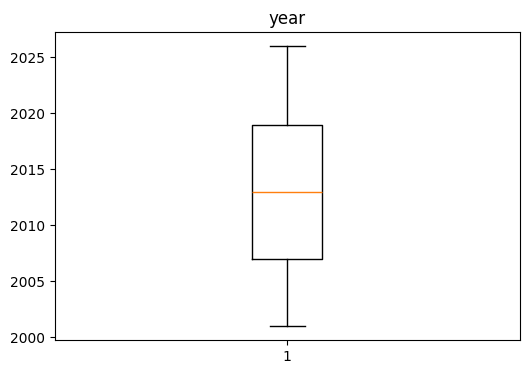

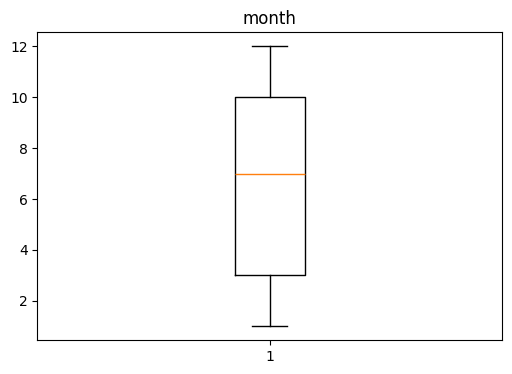

In [45]:
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.show()

In [46]:
numeric_cols = [
    "temp_max_f", "temp_avg_f", "temp_min_f",
    "dew_max_f", "dew_avg_f", "dew_min_f",
    "wind_max_mph", "wind_avg_mph", "wind_min_mph",
    "pressure_max_in", "pressure_avg_in", "pressure_min_in"
]

df[numeric_cols] = df[numeric_cols].astype(float)
df = df.sort_values("date").reset_index(drop=True)

# Para temp_max_f
mask = df["temp_max_f"] > 110
df["temp_max_f"] = df["temp_max_f"].mask(mask).interpolate(limit_direction="both")

# Para temp_min_f
mask = df["temp_min_f"] < 20
df["temp_min_f"] = df["temp_min_f"].mask(mask).interpolate(limit_direction="both")

# Para dew_max_f
mask = df["dew_max_f"] > 83
df["dew_max_f"] = df["dew_max_f"].mask(mask).interpolate(limit_direction="both")

# Para dew_min_f
mask = df["dew_min_f"] < 10
df["dew_min_f"] = df["dew_min_f"].mask(mask).interpolate(limit_direction="both")

# Para wind_max_mph
mask = df["wind_max_mph"] > 75
df["wind_max_mph"] = df["wind_max_mph"].mask(mask).interpolate(limit_direction="both")

# Para wind_avg_mph
mask = df["wind_avg_mph"] > 30
df["wind_avg_mph"] = df["wind_avg_mph"].mask(mask).interpolate(limit_direction="both")

# Para pressure_max_in
mask = (df["pressure_max_in"] < 29.2) | (df["pressure_max_in"] > 30.8)
df["pressure_max_in"] = df["pressure_max_in"].mask(mask).interpolate(limit_direction="both")

# Para pressure_avg_in
mask = (df["pressure_avg_in"] < 29.2) | (df["pressure_avg_in"] > 30.8)
df["pressure_avg_in"] = df["pressure_avg_in"].mask(mask).interpolate(limit_direction="both")

# Para pressure_min_in
mask = (df["pressure_min_in"] < 29.0) | (df["pressure_min_in"] > 30.8)
df["pressure_min_in"] = df["pressure_min_in"].mask(mask).interpolate(limit_direction="both")

# Para mantener min <= avg <= max en cada variable
for min_col, avg_col, max_col in [
    ("temp_min_f", "temp_avg_f", "temp_max_f"),
    ("dew_min_f", "dew_avg_f", "dew_max_f"),
    ("wind_min_mph", "wind_avg_mph", "wind_max_mph"),
    ("pressure_min_in", "pressure_avg_in", "pressure_max_in")
]:
    ordered = np.sort(df[[min_col, avg_col, max_col]].to_numpy(), axis=1)
    df[min_col] = ordered[:, 0]
    df[avg_col] = ordered[:, 1]
    df[max_col] = ordered[:, 2]



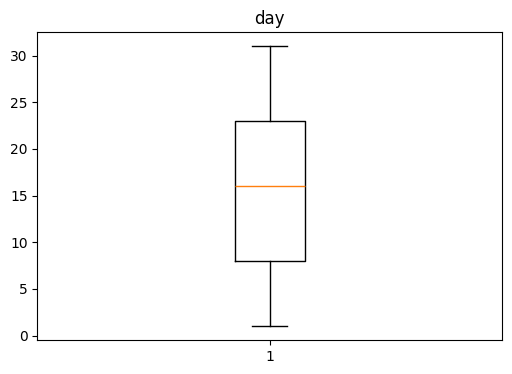

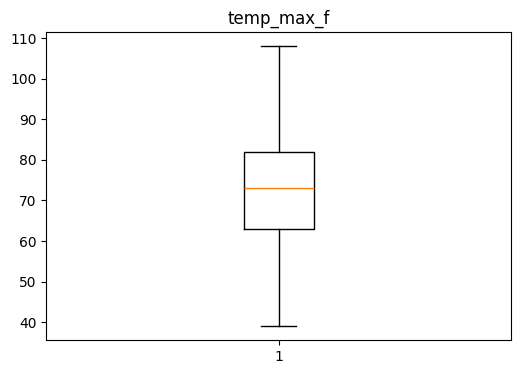

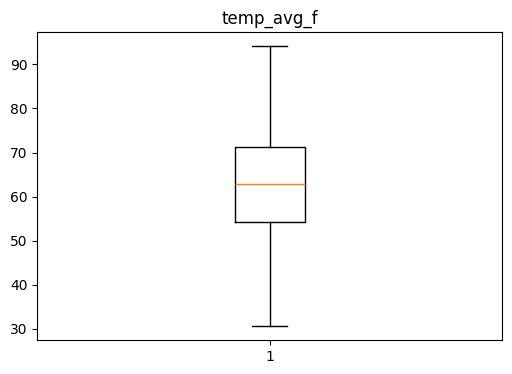

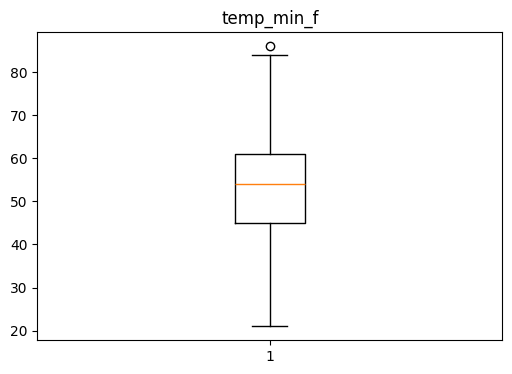

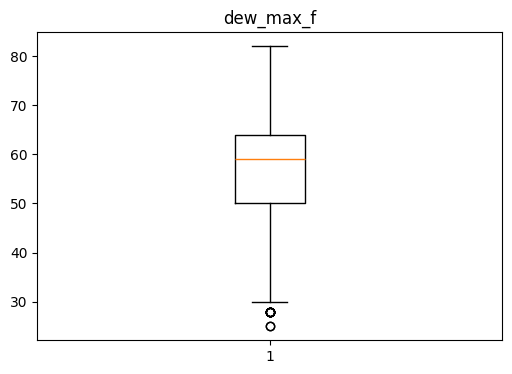

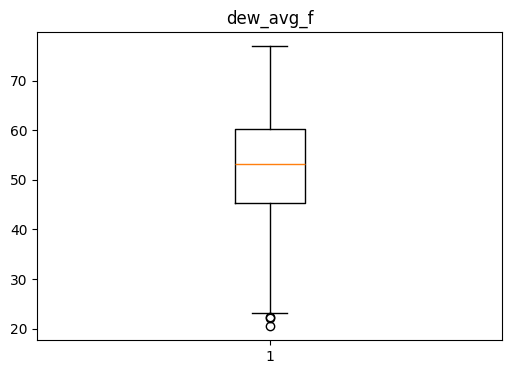

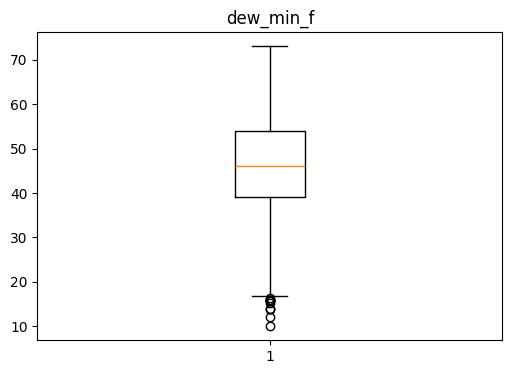

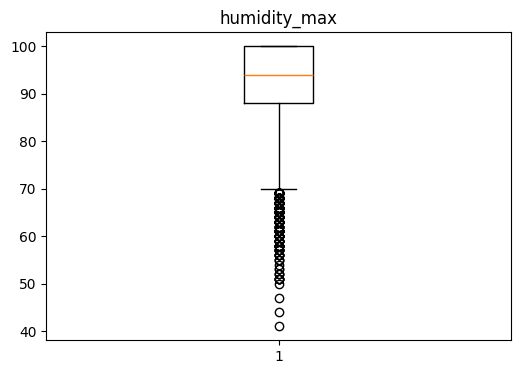

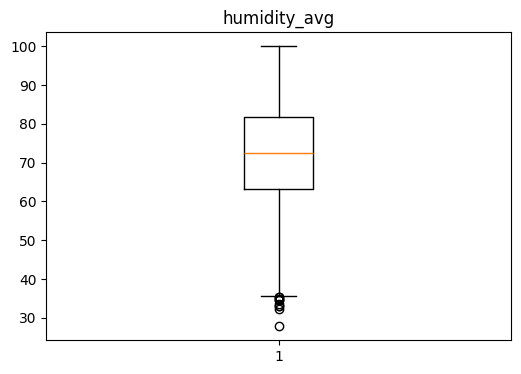

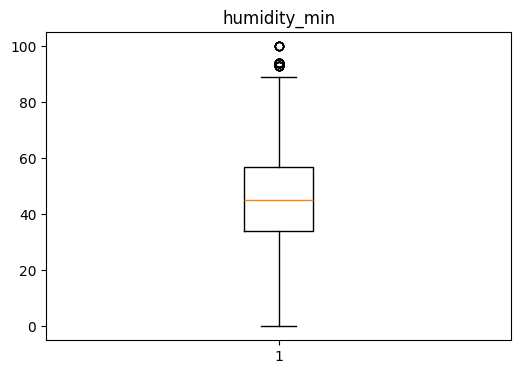

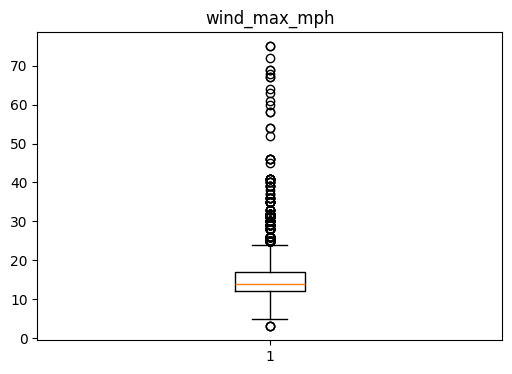

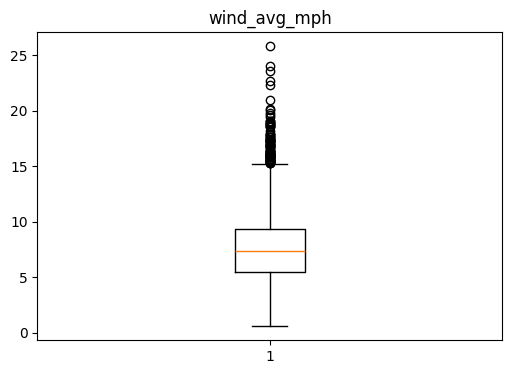

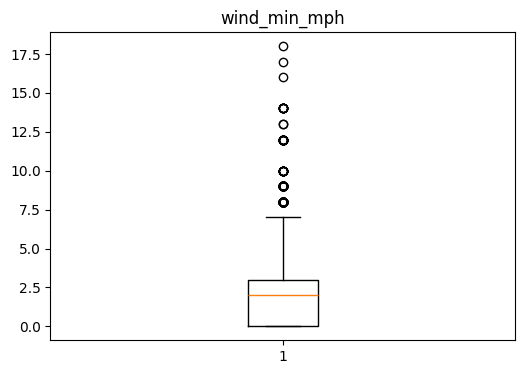

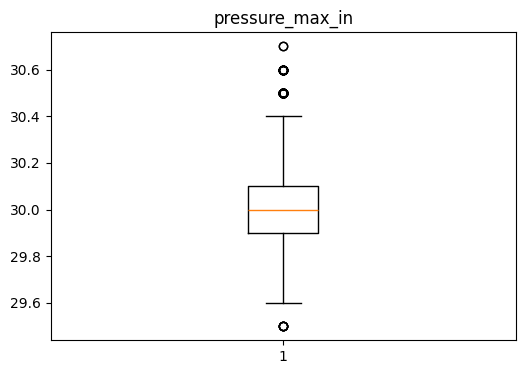

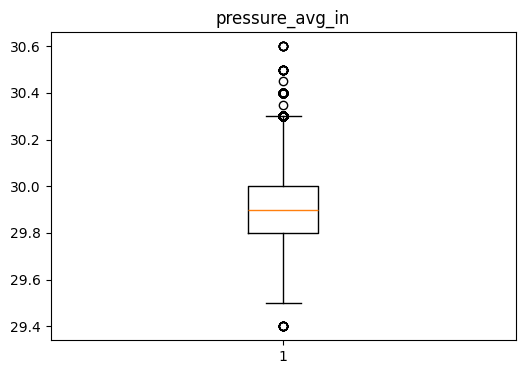

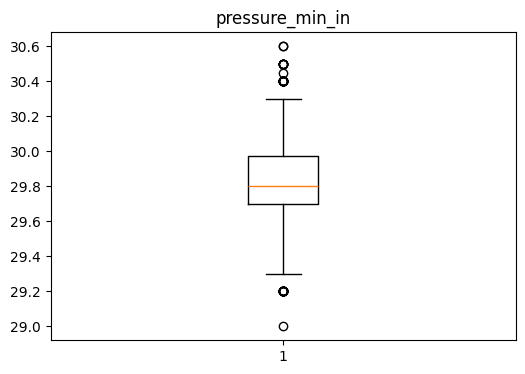

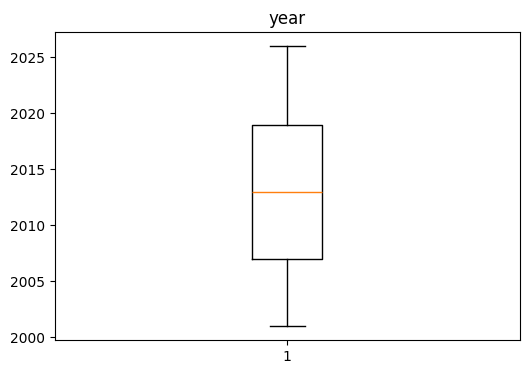

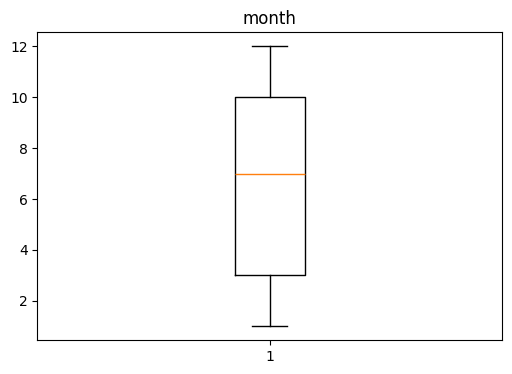

In [47]:
# Boxplot para cada columna numerica
num_cols = df.select_dtypes(include="number").columns
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.show()

Como se puede apreciar, la mayoria de valores atipicos desaparecieron. 

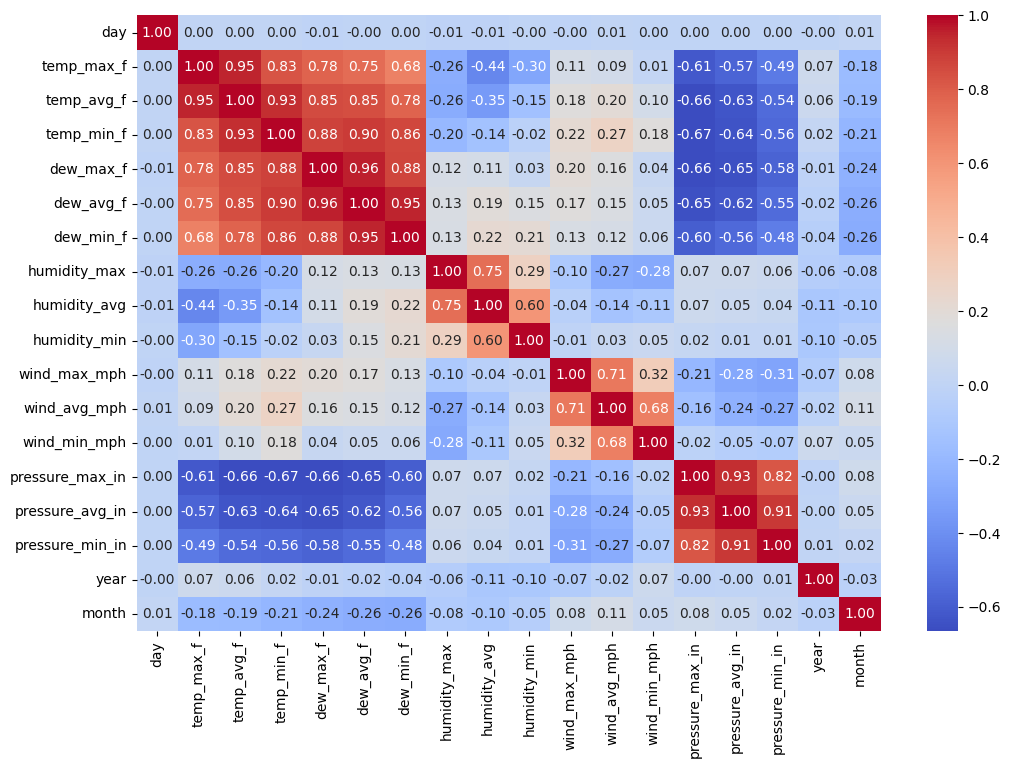

In [48]:
# Matriz de correlaccion con seaborn
corr_df = df.select_dtypes(include="number").corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_df, annot=True, cmap = "coolwarm", fmt = ".2f")
plt.show()

Las relaciones más importantes observadas son las siguientes:

1. Temperatura y punto de rocío presentan una correlación positiva fuerte, lo cual tiene sentido para Ezeiza. En general, cuando aumenta la temperatura, también aumenta el contenido de humedad en el aire. Esto se ve especialmente en las correlaciones entre temp_avg_f, temp_min_f y las variables dew_*, con valores altos y consistentes.

2. Temperatura y humedad relativa muestran una relación negativa, sobre todo con humidity_avg y humidity_min. Esto también es esperable: a medida que sube la temperatura, la humedad relativa suele bajar, aun cuando el aire contenga bastante vapor de agua.

3. Presión y temperatura / punto de rocío presentan correlaciones negativas claras. En términos meteorológicos, esto sugiere que los días más cálidos y húmedos suelen estar asociados a situaciones de presión más baja, mientras que las presiones más altas acompañan condiciones más estables, frescas y secas.

4. Las variables de viento (wind_min_mph, wind_avg_mph, wind_max_mph) están positivamente correlacionadas entre sí, lo cual es consistente: si un día fue ventoso en promedio, también es esperable que aumenten sus máximos y mínimos.

5. La relación entre viento y presión es negativa moderada, algo razonable desde el punto de vista físico, ya que los días más dinámicos suelen darse en contextos de sistemas de baja presión o mayor gradiente bárico.
